<a href="https://colab.research.google.com/github/deeksha216/Deep_Learning-lab/blob/main/DL_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Epoch 1/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 241s 1s/step - accuracy: 0.7754 - loss: 0.4603 - val_accuracy: 0.8584 - val_loss: 0.3364
Epoch 2/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 230s 1s/step - accuracy: 0.8982 - loss: 0.2615 - val_accuracy: 0.8716 - val_loss: 0.3006
Epoch 3/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 185s 944ms/step - accuracy: 0.9247 - loss: 0.2026 - val_accuracy: 0.8587 - val_loss: 0.3309
Epoch 4/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 223s 1s/step - accuracy: 0.9462 - loss: 0.1512 - val_accuracy: 0.8675 - val_loss: 0.3485
Epoch 5/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 183s 932ms/step - accuracy: 0.9558 - loss: 0.1239 - val_accuracy: 0.8587 - val_loss: 0.4396
Epoch 6/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 201s 925ms/step - accuracy: 0.9605 - loss: 0.1111 - val_accuracy: 0.8627 - val_loss: 0.4237
Epoch 7/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 199s 910ms/step - accuracy: 0.9756 - loss: 0.0735 - val_accuracy: 0.8490 - val_loss: 0.6695
Epoch 8/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 181s 923ms/step - accuracy: 0.9710 - loss: 0.

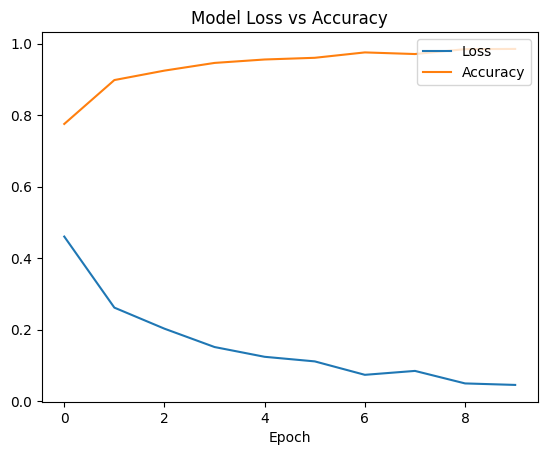

In [2]:
import numpy as np
from keras.preprocessing.sequence import pad_sequences
from keras.models import Sequential
from keras.layers import Dense, Dropout, Embedding, LSTM, Bidirectional
from keras.datasets import imdb
from matplotlib import pyplot

n_unique_words = 10000
maxlen = 200
batch_size = 128

(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=n_unique_words)

x_train = pad_sequences(x_train, maxlen=maxlen)
x_test = pad_sequences(x_test, maxlen=maxlen)

y_train = np.array(y_train)
y_test = np.array(y_test)

model = Sequential()

model.add(Embedding(n_unique_words, 128, input_length=maxlen))
model.add(Bidirectional(LSTM(64)))
model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid'))

model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

history = model.fit(
    x_train,
    y_train,
    batch_size=batch_size,
    epochs=10,
    validation_data=(x_test, y_test)
)

test_loss, test_acc = model.evaluate(x_test, y_test)

print("Test loss:", test_loss)
print("Test accuracy:", test_acc)

print(history.history['loss'])
print(history.history['accuracy'])

pyplot.plot(history.history['loss'])
pyplot.plot(history.history['accuracy'])
pyplot.title('Model Loss vs Accuracy')
pyplot.xlabel('Epoch')
pyplot.legend(['Loss', 'Accuracy'], loc='upper right')
pyplot.show()